# 02-linear-regression-medical-insurance-cost

**1. CARGA DEL DATASET**

In [2]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# CARGO LOS DATOS
url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"
total_data = pd.read_csv(url)
total_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
total_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
total_data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [6]:
total_data.shape

(1338, 7)

In [7]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
total_data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

- El dataset contiene 1338 filas y 7 columnas relacionadas con el coste del seguro médico de una persona.
- Incluye variables relacionnadas con los clientes como su edad, sexo, índice de masa corporal y número de hijos.
- El objetivo es calcular, en función de los datos fisiológicos de los clientes, cuál va a ser el coste que debe asumir cada cliente.

In [9]:
# TODOS LOS VALORES FALTANTES DEL DATAFRAME
total_data.isna().sum().sum()

np.int64(0)

In [10]:
# CUENTO LOS VALORES NULOS PARA CADA COLUMNA
total_data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending=False)

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

In [12]:
total_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

- No se encontraron valores nulos.

In [13]:
# POSIBLES DATOS CATEGÓRICOS
total_data.select_dtypes(include=['object']).columns

/tmp/ipykernel_4936/1623080498.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  total_data.select_dtypes(include=['object']).columns


Index(['sex', 'smoker', 'region'], dtype='str')

**2. LIMPIEZA INICIAL**

In [14]:
total_data.duplicated().sum()

np.int64(1)

In [15]:
total_data[total_data.duplicated() == True]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [16]:
total_data.value_counts()

age  sex     bmi     children  smoker  region     charges    
19   male    30.590  0         no      northwest  1639.56310     2
     female  27.900  0         yes     southwest  16884.92400    1
18   male    33.770  1         no      southeast  1725.55230     1
28   male    33.000  3         no      southeast  4449.46200     1
33   male    22.705  0         no      northwest  21984.47061    1
                                                                ..
50   male    30.970  3         no      northwest  10600.54830    1
18   female  31.920  0         no      northeast  2205.98080     1
             36.850  0         no      southeast  1629.83350     1
21   female  25.800  0         no      southwest  2007.94500     1
61   female  29.070  0         yes     northwest  29141.36030    1
Name: count, Length: 1337, dtype: int64

In [17]:
total_data = total_data.drop_duplicates(keep="first")
print(total_data.shape)
total_data.head()

(1337, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**3. ANÁLISIS DE VARIABLES**

- Variables categóricas: 'sex', 'smoker', 'region'
- Variables numéricas: 'age', 'bmi', 'children', 'charges'

<Axes: xlabel='charges', ylabel='Count'>

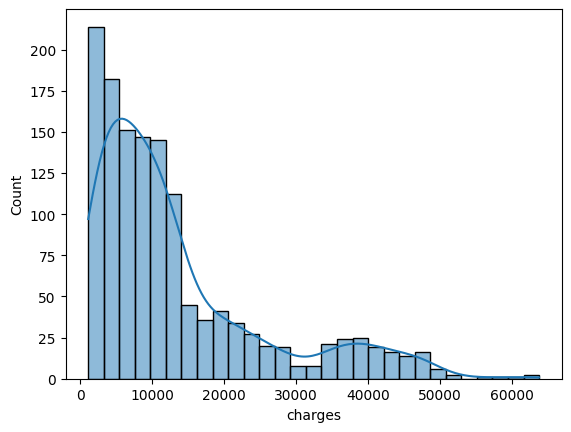

In [18]:
# DISTRIBUCIÓN DE CHARGES
sns.histplot(total_data["charges"], kde=True)

**Variables categóricas**

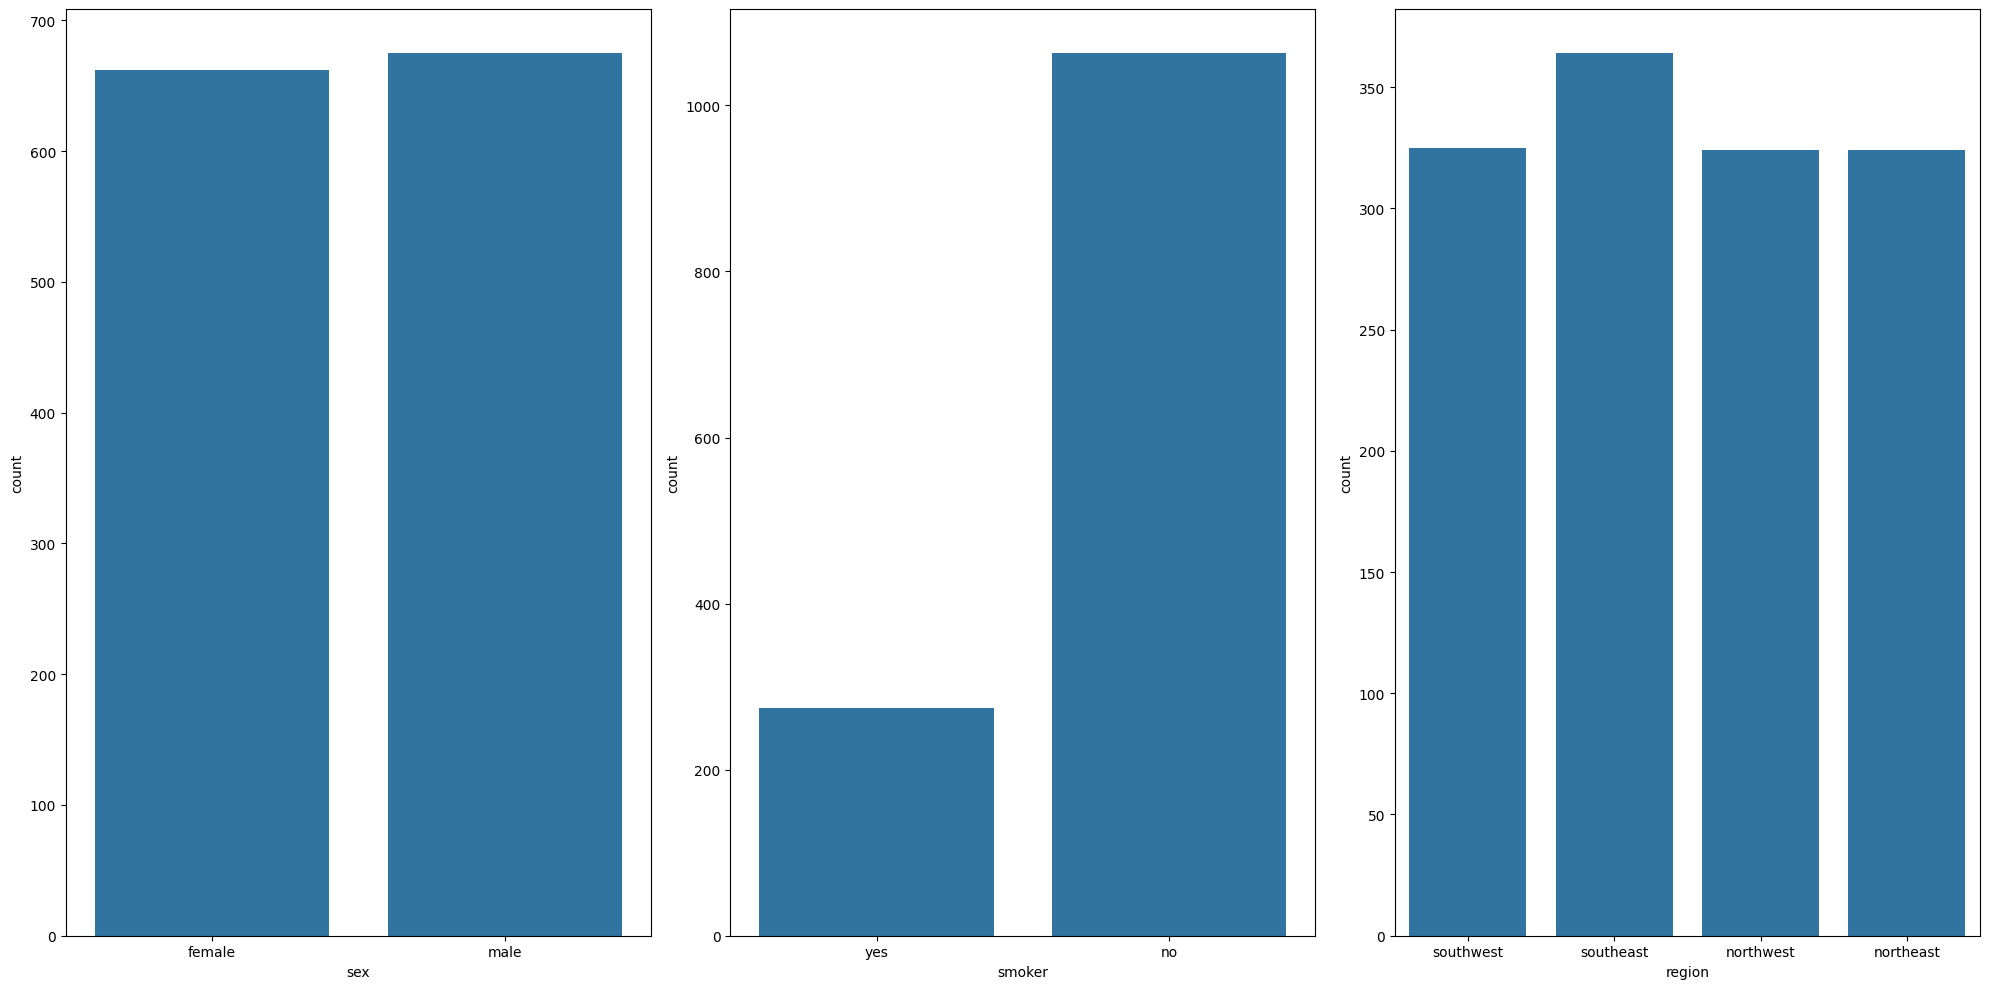

In [19]:
# HISTOGRA MÚLTIPLE
fig, axis = plt.subplots(1, 3, figsize=(20, 10))

sns.countplot(data=total_data, x='sex', ax=axis[0])
sns.countplot(data=total_data, x='smoker', ax=axis[1])
sns.countplot(data=total_data, x='region', ax=axis[2])

plt.tight_layout()
plt.show()

**Variables numéricas**

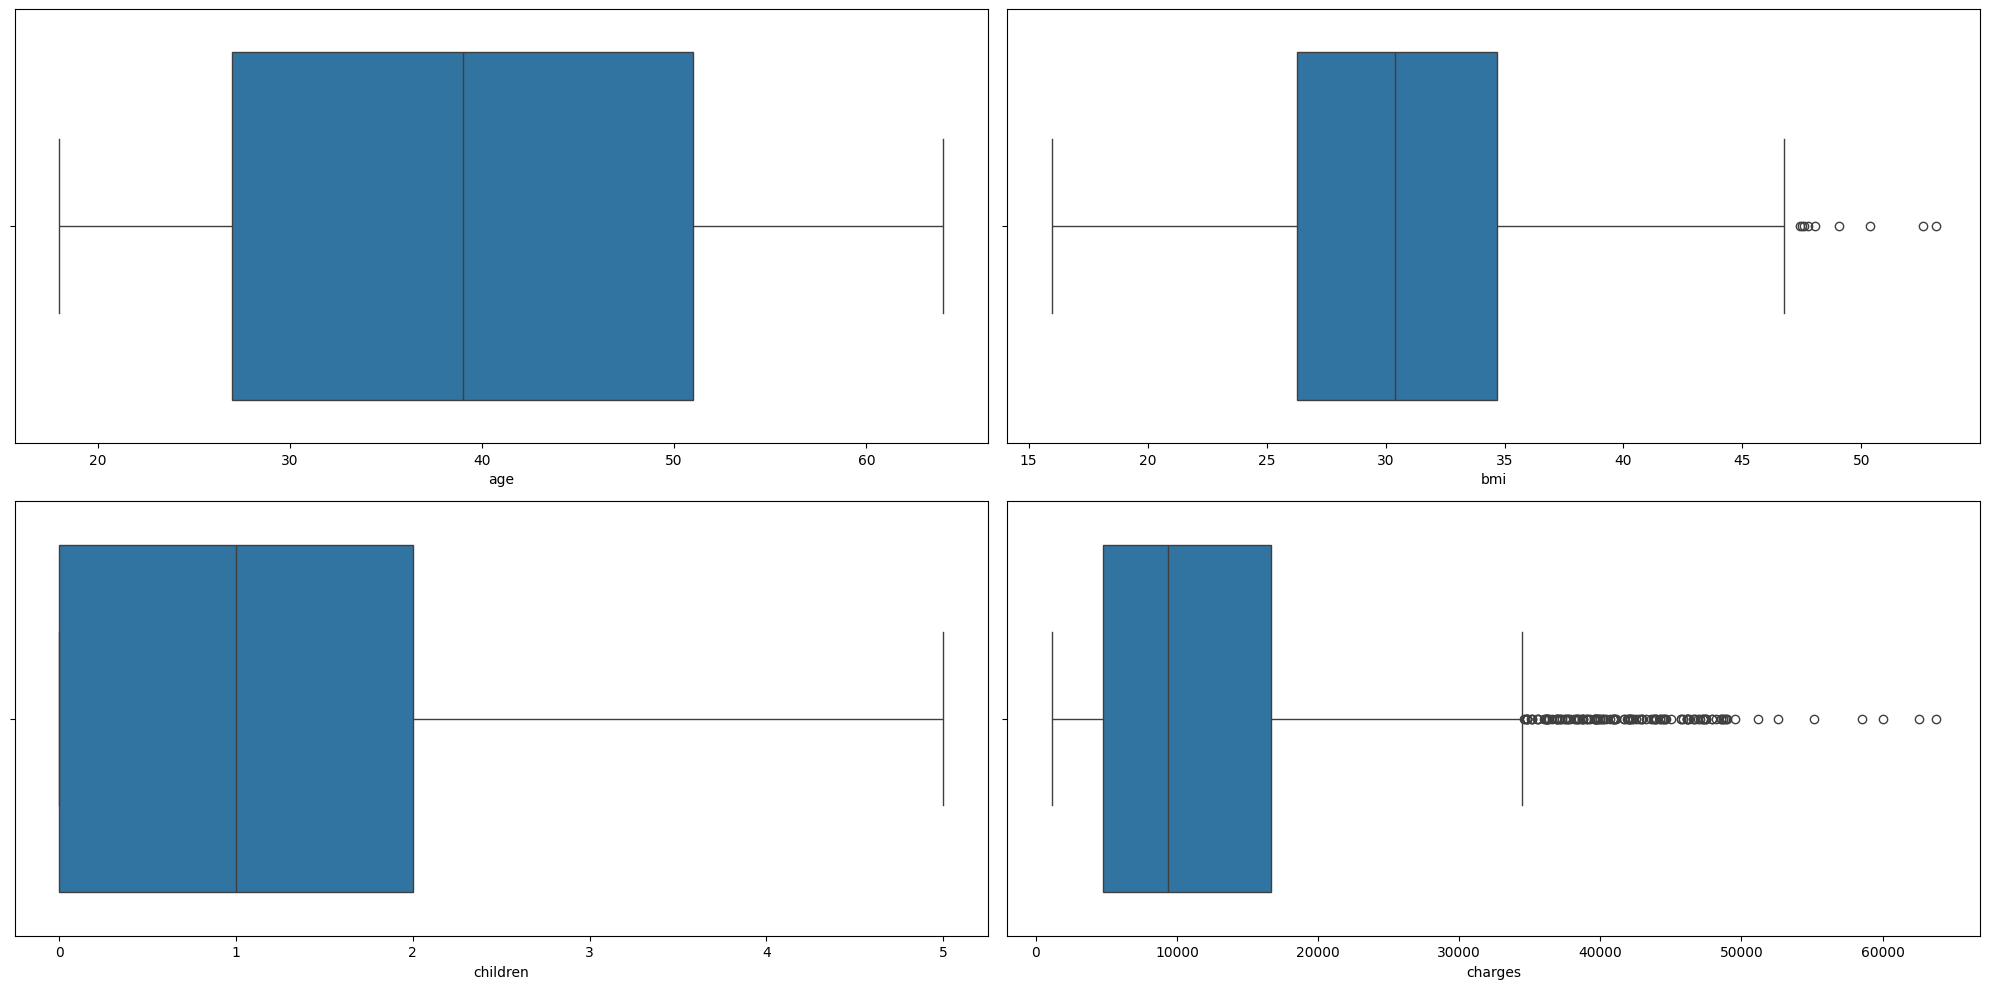

In [20]:
fig, axis = plt.subplots(2, 2, figsize = (20, 10))

sns.boxplot(ax = axis[0, 0], x = total_data["age"])
sns.boxplot(ax = axis[0, 1], x = total_data["bmi"])
sns.boxplot(ax = axis[1, 0], x = total_data["children"])
sns.boxplot(ax = axis[1, 1], x = total_data["charges"])

plt.tight_layout()
plt.show()

**4. RELACIONES ENTRE VARIABLES**

**Análisis numérico-numérico**

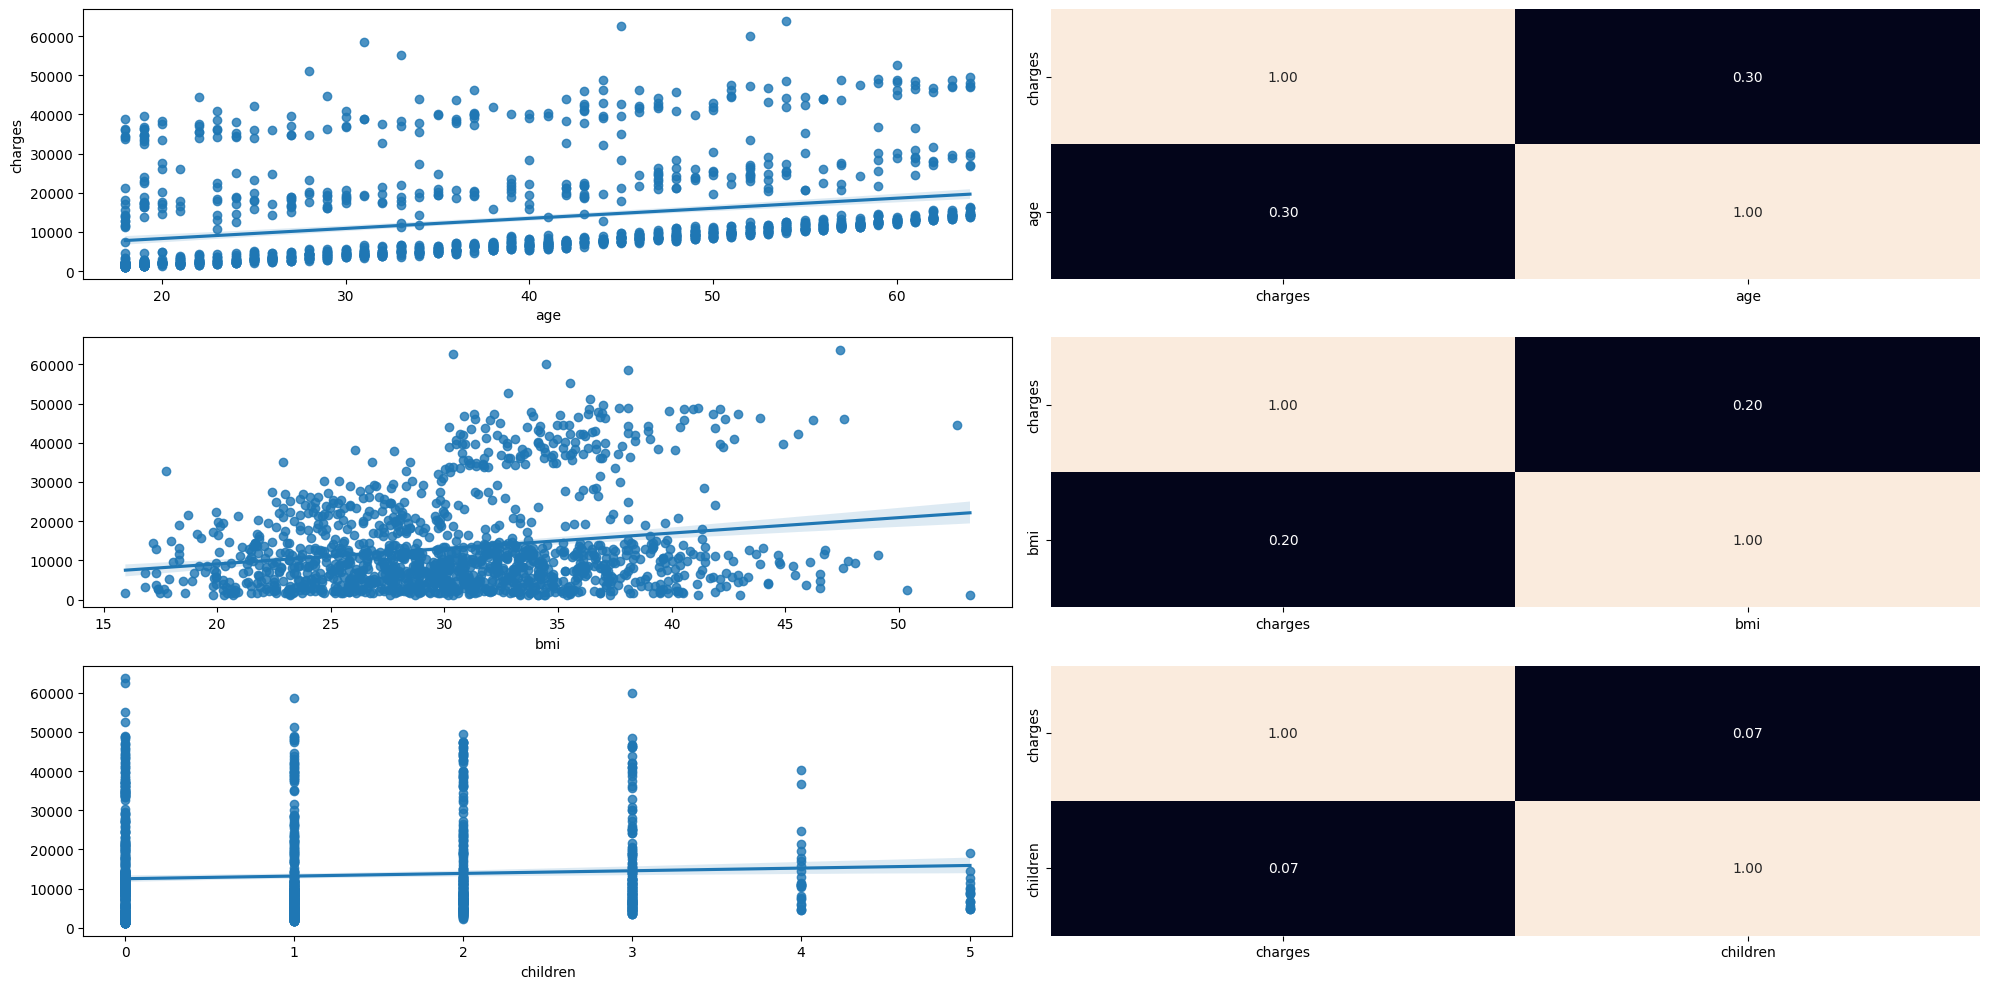

In [21]:
fig, axis = plt.subplots(3, 2, figsize=(20, 10))

# DIAGRAMA DE DISPERSIÓN MÚLTIPLE
sns.regplot(ax = axis[0, 0], data = total_data, x = "age", y = "charges")
sns.heatmap(total_data[["charges", "age"]].corr(), 
            annot = True, fmt = ".2f", ax = axis[0, 1], cbar = False)

sns.regplot(ax = axis[1, 0], data = total_data, x = "bmi", y = "charges").set(ylabel = None)
sns.heatmap(total_data[["charges", "bmi"]].corr(), 
            annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

sns.regplot(ax = axis[2, 0], data = total_data, x = "children", y = "charges").set(ylabel = None)
sns.heatmap(total_data[["charges", "children"]].corr(), 
            annot = True, fmt = ".2f", ax = axis[2, 1], cbar = False)

plt.tight_layout()
plt.show()

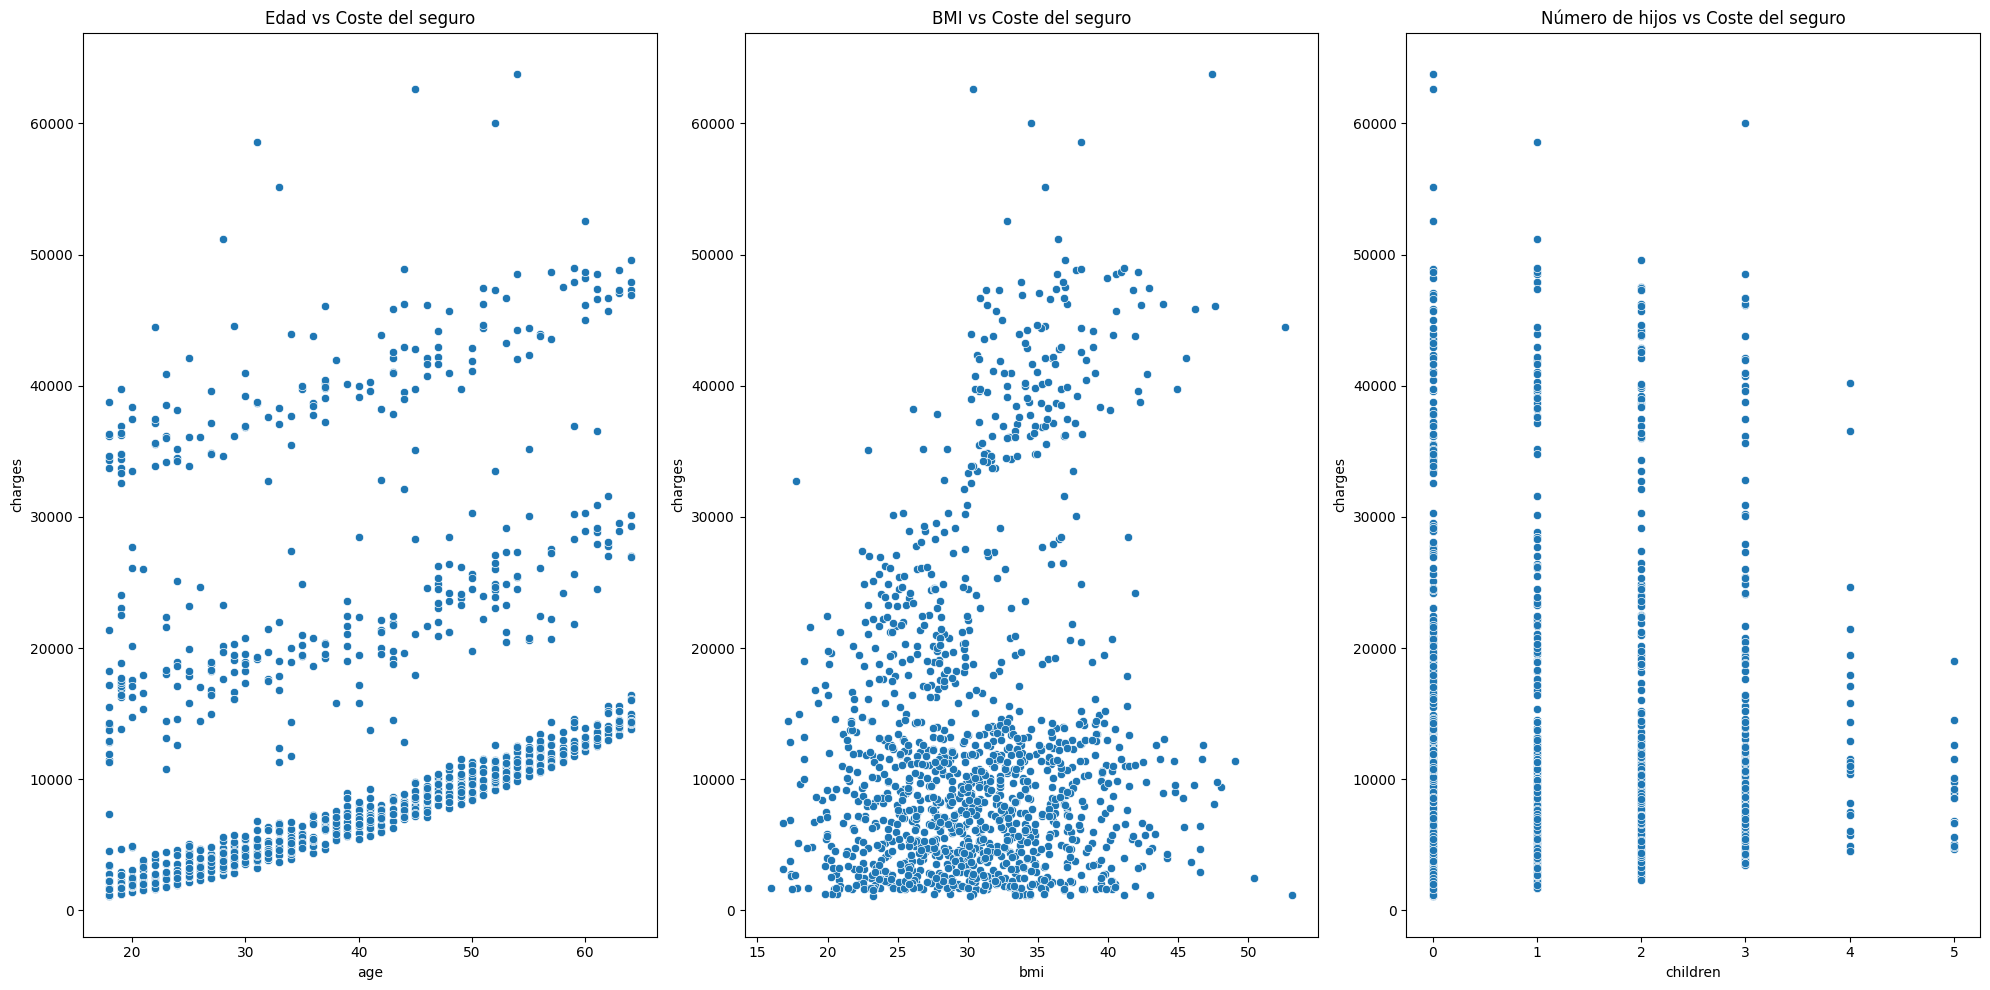

In [22]:
fig, axis = plt.subplots(1, 3, figsize=(20, 10))

sns.scatterplot(data=total_data, x="age", y="charges", ax=axis[0])
axis[0].set_title("Edad vs Coste del seguro")

sns.scatterplot(data=total_data, x="bmi", y="charges", ax=axis[1])
axis[1].set_title("BMI vs Coste del seguro")

sns.scatterplot(data=total_data, x="children", y="charges", ax=axis[2])
axis[2].set_title("Número de hijos vs Coste del seguro")

plt.tight_layout()
plt.show()

- A medida que aumenta la edad del asegurado, el coste del seguro tiende a aumentar. Sin embargo, la relación no es muy fuerte, lo que indica que otros factores también influyen en el precio del seguro.
- En el scatterplot, también se observa que las personas mayores tienden a tener costes más altos.
- Un mayor índice de masa corporal parece estar asociado con mayores costes médicos, pero la relación es relativamente débil. Los puntos están muy dispersos.
- El número de hijos no parece influir significativamente en el coste del seguro médico.
- La edad parece ser la variable numérica más relacionada con el coste del seguro, seguida por el índice de masa corporal.

**Análisis categórico-categórico**

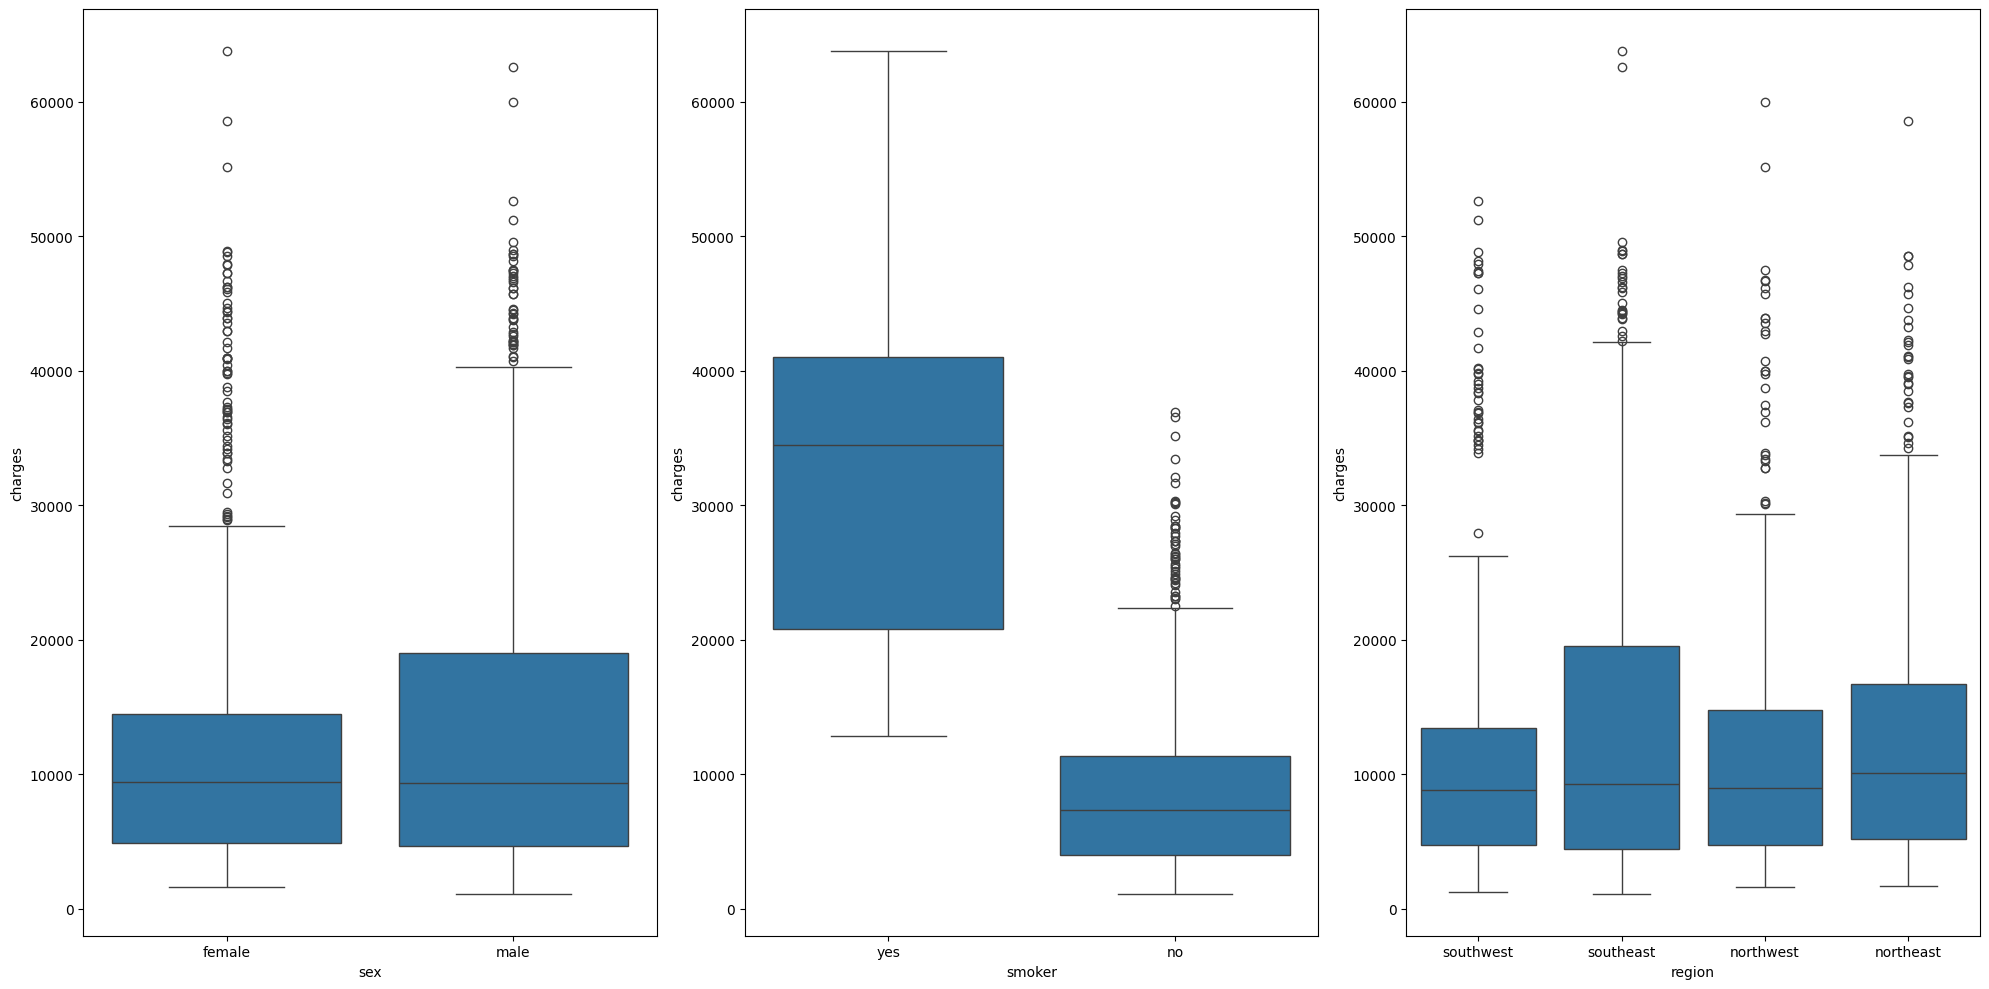

In [23]:
# Boxplots de variables categóricas: 'sex', 'smoker', 'region'
fig, axis = plt.subplots(1, 3, figsize=(20, 10))

sns.boxplot(data=total_data, x="sex", y="charges", ax=axis[0])
sns.boxplot(data=total_data, x="smoker", y="charges", ax=axis[1])
sns.boxplot(data=total_data, x="region", y="charges", ax=axis[2])

plt.tight_layout()
plt.show()

- Las distribuciones de hombres y mujeres son bastante similares. La mediana del coste del seguro es muy parecida entre ambos grupos. Hay outliers altos en ambos casos.
- Los fumadores tienen costes muchísimo más altos. La mediana de los fumadores es mucho mayor que la de los no fumadores.
- El hábito de fumar tiene un impacto muy significativo en el coste del seguro médico. Los fumadores presentan primas considerablemente más altas que los no fumadores.
- Las distribuciones entre regiones son bastante similares. No hay diferencias muy marcadas en el coste del seguro entre las distintas regiones. La región podría no ser un factor determinante en la predicción del precio del seguro.

**Análisis numérico-categórico**

/tmp/ipykernel_4936/2313436515.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data_corr.select_dtypes(include="object").columns:


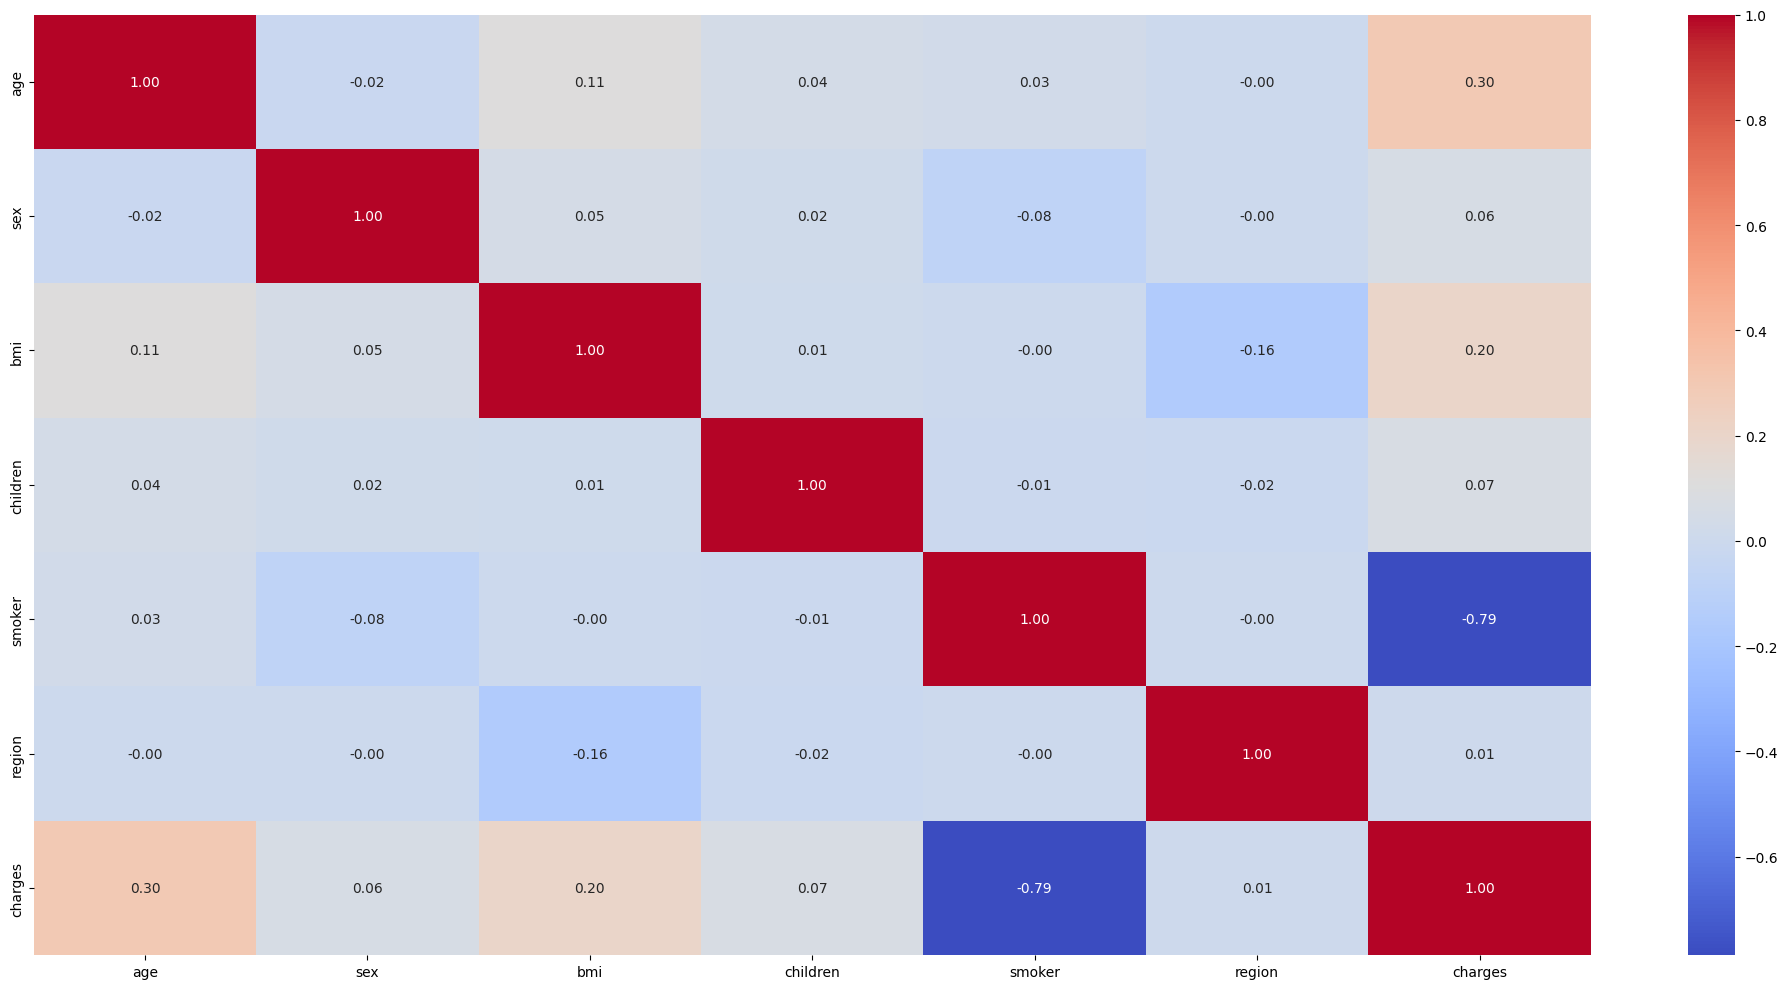

In [24]:
data_corr = total_data.copy()

for col in data_corr.select_dtypes(include="object").columns:
    data_corr[col] = pd.factorize(data_corr[col])[0]

fig, ax= plt.subplots(figsize=(20, 10))
sns.heatmap(data_corr.corr(method="pearson"),
            annot=True, fmt=".2f", cmap="coolwarm", ax=ax)

plt.tight_layout()
plt.show()

- El hábito de fumar es la variable con mayor relación con el coste del seguro médico, lo que indica que los fumadores tienen primas considerablemente más altas.
- A medida que aumenta la edad del asegurado, el coste del seguro tiende a incrementarse.
- Un mayor índice de masa corporal parece estar asociado con mayores costes médicos, aunque la relación no es muy fuerte (0.20).
- El número de hijos no parece tener una influencia significativa en el coste del seguro.
- No hay una relación relevante entre el sexo del asegurado y el coste del seguro.
- La región no parece tener impacto en el coste del seguro.

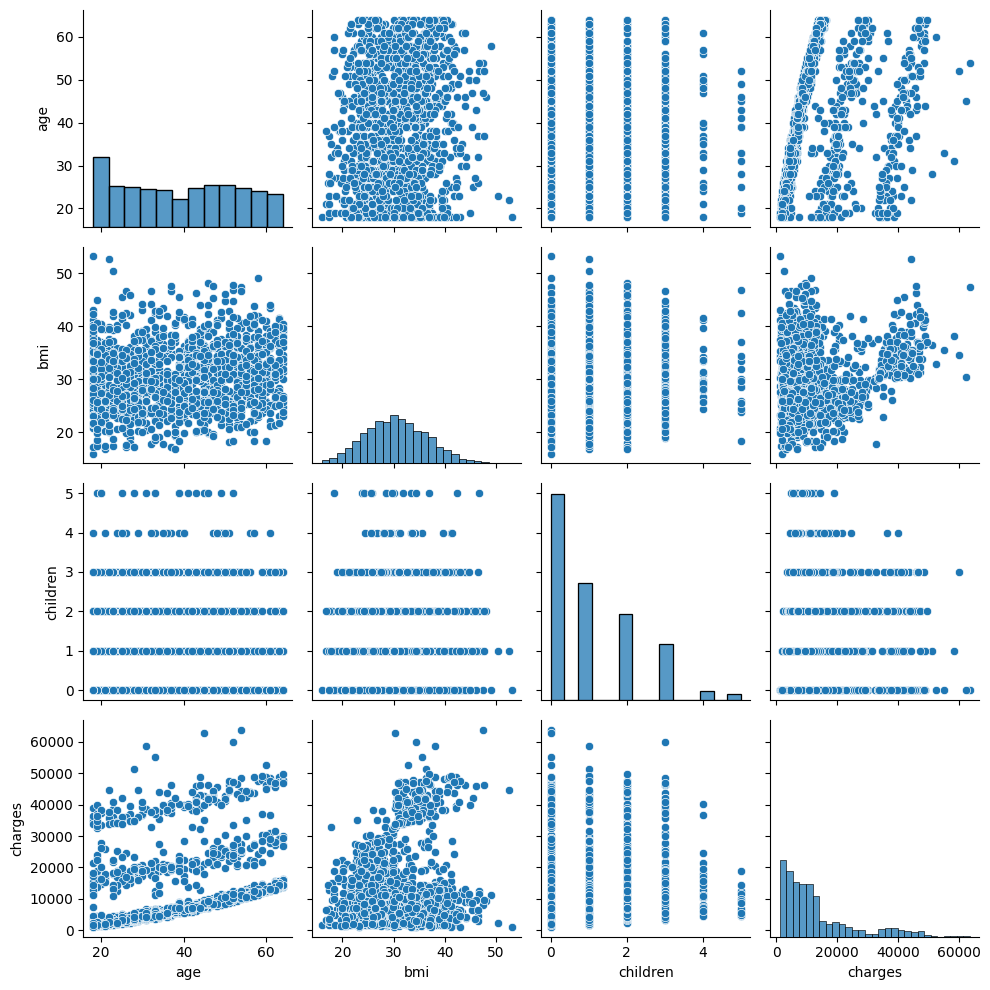

In [25]:
sns.pairplot(data=total_data)
plt.tight_layout()
plt.show()

**5. INGENIERÍA DE CARACTERÍSTICAS**

In [26]:
total_data.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


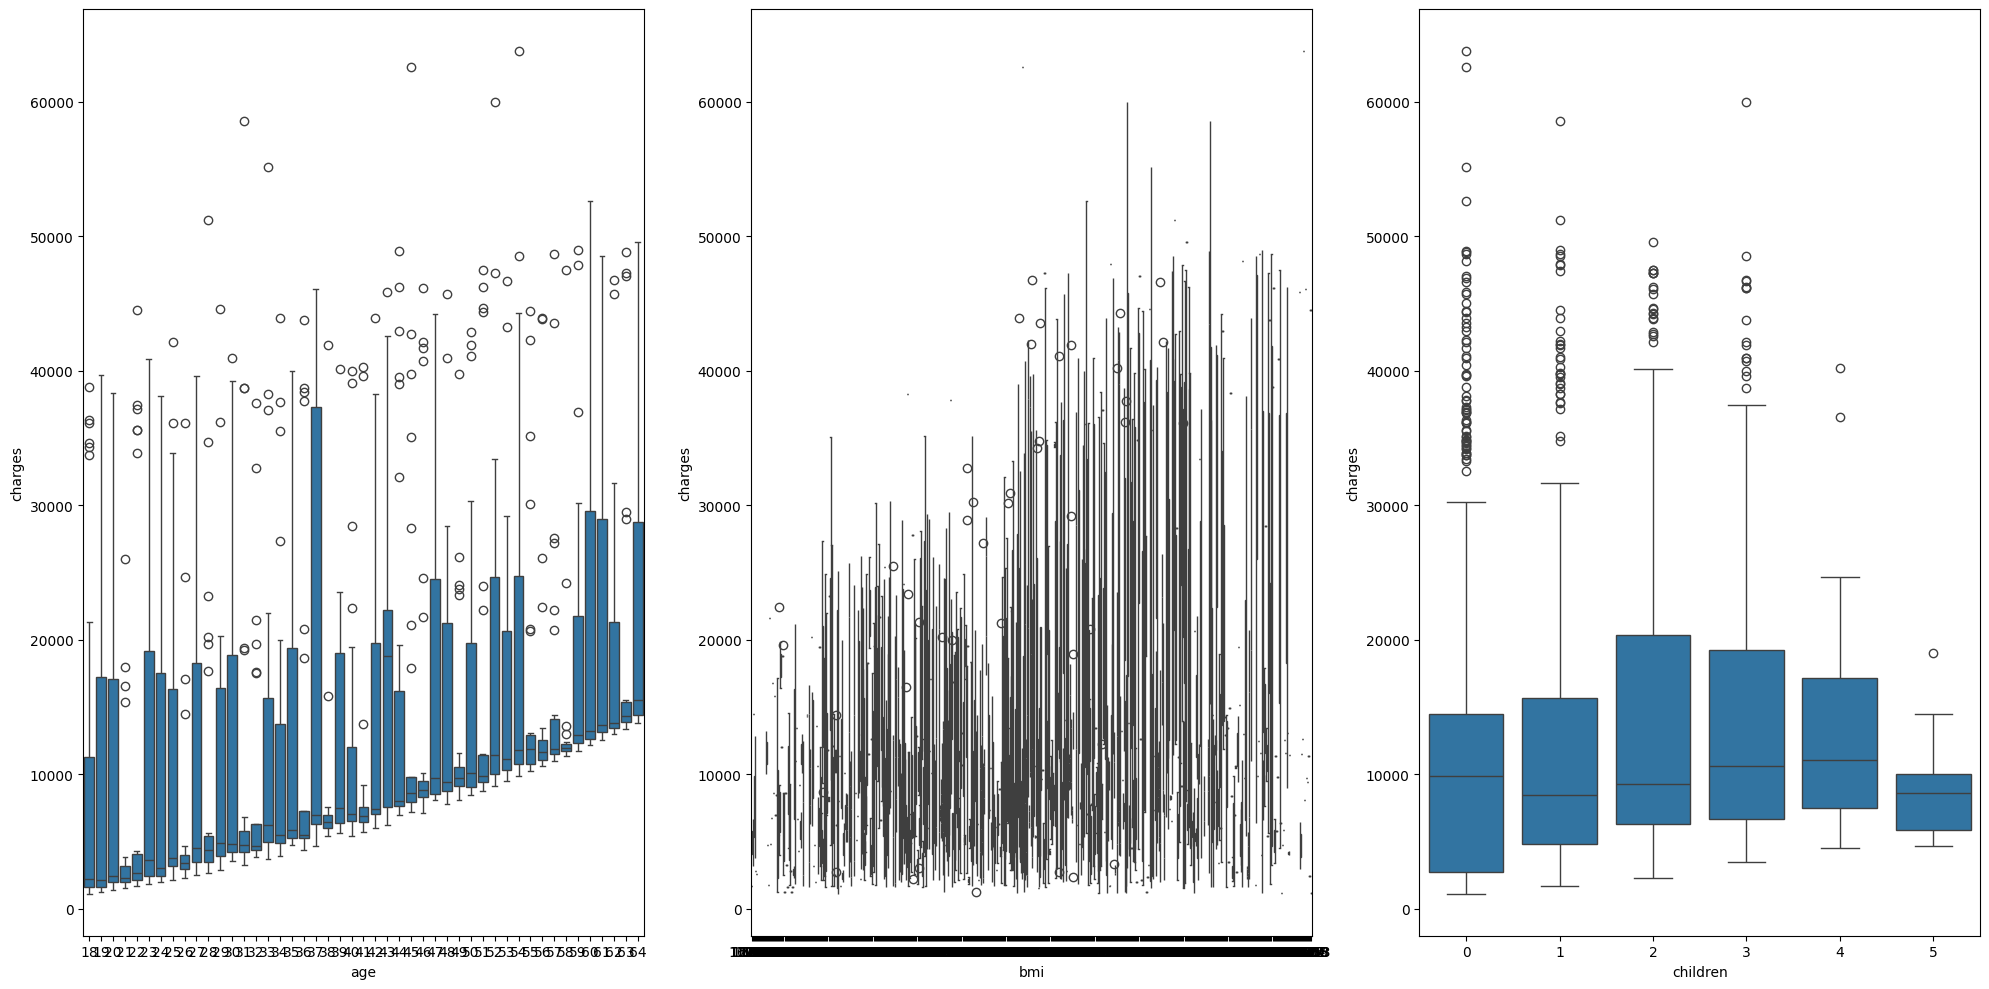

In [27]:
# Boxplots de variables numéricas: 'sex', 'bmi', 'children'

fig, axis = plt.subplots(1, 3, figsize=(20, 10))

sns.boxplot(data=total_data, x="age", y="charges", ax=axis[0])
sns.boxplot(data=total_data, x="bmi", y="charges", ax=axis[1])
sns.boxplot(data=total_data, x="children", y="charges", ax=axis[2])

plt.tight_layout()
plt.show()

In [28]:
# FUNCIÓN REUTILIZABLE PARA DETECTAR OUTLIERS
def detect_outliers_iqr(data, column_name):
    stats = data[column_name].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    outliers = data[(data[column_name] < lower_limit) | (data[column_name] > upper_limit)]

    print(f"\n{column_name.upper()}")
    print(f"  IQR: {iqr:.2f} | Límite inferior: {lower_limit:.2f} | Límite superior: {upper_limit:.2f}")
    print(f"  Outliers: {len(outliers)}")
    
    return outliers, lower_limit, upper_limit

numeric_cols = ['age', 'bmi', 'children', 'charges']

for col in numeric_cols:
    detect_outliers_iqr(total_data, col)


AGE
  IQR: 24.00 | Límite inferior: -9.00 | Límite superior: 87.00
  Outliers: 0

BMI
  IQR: 8.41 | Límite inferior: 13.67 | Límite superior: 47.32
  Outliers: 9

CHILDREN
  IQR: 2.00 | Límite inferior: -3.00 | Límite superior: 5.00
  Outliers: 0

CHARGES
  IQR: 11911.37 | Límite inferior: -13120.72 | Límite superior: 34524.78
  Outliers: 139


**6. TRAIN / TEST SPLIT**

In [29]:
# ONE HOT ENCODING
total_data = pd.get_dummies(total_data, drop_first=True)
total_data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [30]:
# SEPARO X E Y
mi_x = total_data.drop("charges", axis=1)
mi_y = total_data["charges"]

In [31]:
# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(mi_x, mi_y, test_size=0.2, random_state=42)

In [32]:
# LINEAR REGRESSION
model = LinearRegression()

In [33]:
# ENTRENO EL MODELO
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
model.intercept_

np.float64(-11092.652295945958)

In [35]:
model.coef_

array([  248.21072022,   318.70144095,   533.0099888 ,  -101.54205399,
       23077.76459287,  -391.76145478,  -838.91961573,  -659.13975155])

In [36]:
# PREDICCIONES
y_pred = model.predict(X_test)

In [37]:
# MSE
mean_squared_error(y_test, y_pred)

35478020.67523562

- El Error Cuadrático Medio (MSE) de 35478020 indica que, en promedio, las predicciones se desvían del valor real alrededor de 5956 unidades.

In [38]:
# R²
r2_score(y_test, y_pred)

0.8069287081198011

- El modelo explica aproximadamente el 80% de la variabilidad del coste del seguro.

**7. OPTIMIZACIÓN DEL MODELO**

In [39]:
# APLICAR LOG AL TARGET ANTES DEL SPLIT
mi_x2 = total_data.drop(["charges", "children"], axis=1)
mi_y2 = np.log(total_data["charges"])

In [40]:
# NUEVO SPLIT
X_train2, X_test2, y_train2, y_test2 = train_test_split(mi_x2, mi_y2, test_size=0.2, random_state=42)

In [42]:
# NUEVO MODELO
model2 = LinearRegression()
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

In [43]:
# EVALUACIÓN
print("EVALUACIÓN DEL MODELO OPTIMIZADO")
print(f"R² Train: {r2_score(y_train2, model2.predict(X_train2)):.4f}")
print(f"R² Test:  {r2_score(y_test2, y_pred2):.4f}")
print(f"RMSE Train: {np.sqrt(mean_squared_error(y_train2, model2.predict(X_train2))):.4f}")
print(f"RMSE Test:  {np.sqrt(mean_squared_error(y_test2, y_pred2)):.4f}")

EVALUACIÓN DEL MODELO OPTIMIZADO
R² Train: 0.7327
R² Test:  0.8098
RMSE Train: 0.4687
RMSE Test:  0.4202


- El R² en test es mayor al de train, lo que puede deberse a la distribución aleatoria del split. No parece haber overfitting porque ambos valores son similares.

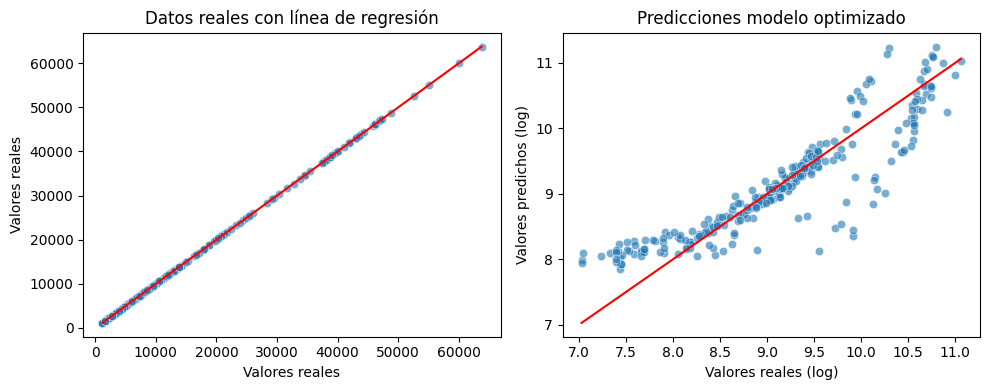

In [46]:
# COMPARO EL VALOR PREDICHO VS EL VALOR REAL
fig, axis = plt.subplots(1, 2, figsize=(10, 4))

# DATOS REALES (modelo original)
sns.scatterplot(ax=axis[0], x=y_test, y=y_test, alpha=0.6)
sns.lineplot(ax=axis[0], x=[y_test.min(), y_test.max()], 
             y=[y_test.min(), y_test.max()], color='red')
axis[0].set_title("Datos reales con línea de regresión")
axis[0].set_xlabel("Valores reales")
axis[0].set_ylabel("Valores reales")

# PREDICCIONES (modelo optimizado con log)
sns.scatterplot(ax=axis[1], x=y_test2, y=y_pred2, alpha=0.6)
sns.lineplot(ax=axis[1], x=[y_test2.min(), y_test2.max()], 
             y=[y_test2.min(), y_test2.max()], color='red')
axis[1].set_title("Predicciones modelo optimizado")
axis[1].set_xlabel("Valores reales (log)")
axis[1].set_ylabel("Valores predichos (log)")

plt.tight_layout()
plt.show()

**8. CONCLUSIONES**

- El dataset original tenía 1338 filas y 7 columnas relacionadas con el coste del seguro médico de una persona.
- Incluye variables relacionnadas con los clientes su edad, sexo, índice de masa corporal y número de hijos.
- El objetivo era calcular, en función de los datos fisiológicos de los clientes, cuál va a ser el coste que debe asumir cada cliente.
- Se eliminó un duplicado. No se encontraron valores nulos.

**Análisis numérico-numérico**
- A medida que aumenta la edad del asegurado, el coste del seguro tiende a aumentar. Sin embargo, la relación no es muy fuerte, lo que indica que otros factores también influyen en el precio del seguro.
- En el scatterplot, también se observa que las personas mayores tienden a tener costes más altos.
- Un mayor índice de masa corporal parece estar asociado con mayores costes médicos, pero la relación es relativamente débil. Los puntos están muy dispersos.
- El número de hijos no parece influir significativamente en el coste del seguro médico.
- La edad parece ser la variable numérica más relacionada con el coste del seguro, seguida por el índice de masa corporal.

**Análisis categórico-categórico**
- Las distribuciones de hombres y mujeres son bastante similares. La mediana del coste del seguro es muy parecida entre ambos grupos. Hay outliers altos en ambos casos.
- Los fumadores tienen costes muchísimo más altos. La mediana de los fumadores es mucho mayor que la de los no fumadores.
- El hábito de fumar tiene un impacto muy significativo en el coste del seguro médico. Los fumadores presentan primas considerablemente más altas que los no fumadores.
- Las distribuciones entre regiones son bastante similares. No hay diferencias muy marcadas en el coste del seguro entre las distintas regiones. La región podría no ser un factor determinante en la predicción del precio del seguro.

**Matriz de correlación**
- El hábito de fumar es la variable con mayor relación con el coste del seguro médico, lo que indica que los fumadores tienen primas considerablemente más altas.
- A medida que aumenta la edad del asegurado, el coste del seguro tiende a incrementarse.
- Un mayor índice de masa corporal parece estar asociado con mayores costes médicos, aunque la relación no es muy fuerte (0.20).
- El número de hijos no parece tener una influencia significativa en el coste del seguro.
- No hay una relación relevante entre el sexo del asegurado y el coste del seguro.
- La región no parece tener impacto en el coste del seguro.

**Conclusiones del proyecto**
- El modelo explica aproximadamente el 80% de la variabilidad del coste del seguro.
- El Error Cuadrático Medio (MSE) de 35478020 indica que, en promedio, las predicciones se desvían del valor real alrededor de 5956 unidades.
- El hábito de fumar es la variable más influyente en el coste del seguro.
- La edad y el BMI tienen una relación moderada.
- Variables como la región o el sexo tienen poco impacto.
- En la evaluación del modelo optimizado, el R² en test es mayor al de train, lo que puede deberse a la distribución aleatoria del split. No parece haber overfitting porque ambos valores son similares.